In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

In [2]:
gt = pd.read_csv('ground_truth.csv')
gt.head()

,id,name,gender,dob,nik,phone,bank_account,credit_card,email,address,decoy_id
0,0,Opung Saefullah,M,1989-09-28,3172012809894507,628582181960,48908386379,5202654235116152,opung_saefullah619@gmail.com,"Jl. Tebet Barat Dalam No. 8, Semarang, Sulawes...",9974659571848144
1,1,Sutan Nasrullah Yulianti,M,1987-09-21,3501012109871292,88595931034,26475255341,5428327648350300,sutan_nasrullah_yulianti411@gmail.com,"Gang Abdul Muis No. 654, Jambi, NB 16155",9989826016962532
2,2,"Dt. Omar Haryanti, M.Pd",F,1987-10-24,3105016410878180,83824238849,63287101226916,5397848018451463,"dt..omar.haryanti,.m.pd@hotmail.com","Gg. Medokan Ayu No. 5, Tarakan, DI Yogyakarta ...",9980454522783883
3,3,Siska Utama,M,1975-09-27,6101012709751744,8592528809,25430391,4718227824896386,siskautama@hotmail.com,"Jalan Otto Iskandardinata No. 19, Prabumulih, ...",9971655859362929
4,4,"Cut Ghaliyati Firmansyah, S.Psi",F,1992-03-07,3175014703924062,628575098393,41051834,5573829973763112,"cutghaliyatifirmansyah,s.psi442@outlook.com","Jl. Ahmad Yani No. 5, Sungai Penuh, SB 72423",9975727650201532


In [3]:
gt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            5000 non-null   int64 
 1   name          5000 non-null   object
 2   gender        5000 non-null   object
 3   dob           5000 non-null   object
 4   nik           5000 non-null   int64 
 5   phone         5000 non-null   int64 
 6   bank_account  5000 non-null   int64 
 7   credit_card   5000 non-null   int64 
 8   email         5000 non-null   object
 9   address       5000 non-null   object
 10  decoy_id      5000 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 429.8+ KB


Missing Values Check

In [5]:
missing = gt.isnull().sum()
missing_ratio = (missing / len(gt)) * 100

missing_gt = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_ratio
})

display(missing_gt)

,missing_count,missing_%
id,0,0.0
name,0,0.0
gender,0,0.0
dob,0,0.0
nik,0,0.0
phone,0,0.0
bank_account,0,0.0
credit_card,0,0.0
email,0,0.0
address,0,0.0


Uniqueness & Collision Checks

In [6]:
cols_to_check = ["nik", "phone", "bank_account", "credit_card", "decoy_id"]

for col in cols_to_check:
    unique_count = gt[col].nunique()
    print(f"{col}: {unique_count} unique out of {len(gt)}")

duplicates = gt.duplicated().sum()
print("Total duplicate rows:", duplicates)

nik: 5000 unique out of 5000
phone: 5000 unique out of 5000
bank_account: 5000 unique out of 5000
credit_card: 5000 unique out of 5000
decoy_id: 5000 unique out of 5000
Total duplicate rows: 0


Gender Distribution

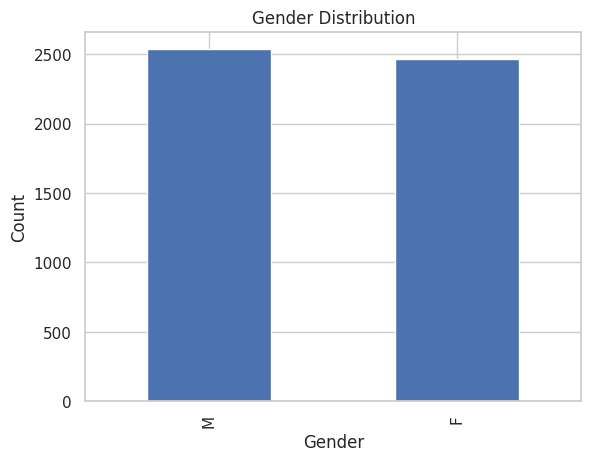

In [8]:
plt.figure()
gt["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Date of Birth Analysis

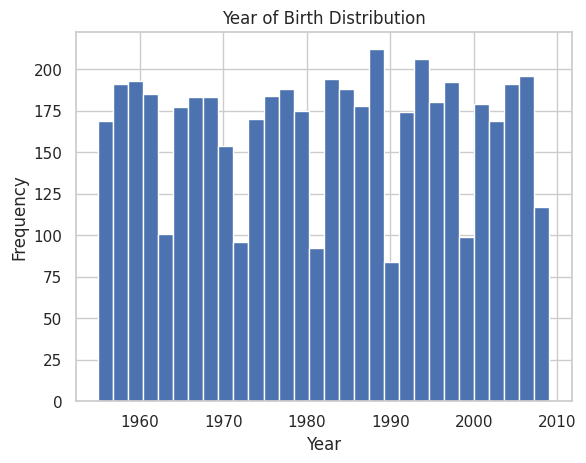

In [9]:
gt["dob"] = pd.to_datetime(gt["dob"], errors="coerce")

plt.figure()
gt["dob"].dt.year.hist(bins=30)
plt.title("Year of Birth Distribution")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

Length-Based Validation

In [11]:
def length_stats(series):
    return series.astype(str).apply(len)

length_gt = pd.DataFrame({
    "nik_len": length_stats(gt["nik"]),
    "phone_len": length_stats(gt["phone"]),
    "bank_len": length_stats(gt["bank_account"]),
    "cc_len": length_stats(gt["credit_card"])
})

display(length_gt.describe())

,nik_len,phone_len,bank_len,cc_len
count,5000.0,5000.000000,5000.000000,5000.0
mean,16.0,11.100400,11.473600,16.0
std,0.0,1.046011,2.296074,0.0
min,16.0,10.000000,8.000000,16.0
25%,16.0,10.000000,9.000000,16.0
50%,16.0,11.000000,11.000000,16.0
75%,16.0,12.000000,13.000000,16.0
max,16.0,13.000000,15.000000,16.0


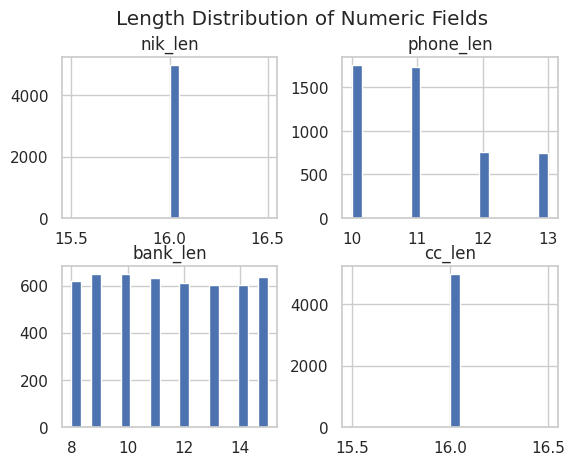

In [12]:
length_gt.hist(bins=20)
plt.suptitle("Length Distribution of Numeric Fields")
plt.show()

Format Validation

In [14]:
def valid_email(email):
    pattern = r"^[\w\.-]+@[\w\.-]+\.\w+$"
    return bool(re.match(pattern, str(email)))

gt["email_valid"] = gt["email"].apply(valid_email)
print("Valid emails:", gt["email_valid"].mean())

Valid emails: 0.7146


In [15]:
# Detect noisy emails (commas, double dots, etc.)
gt["email_noise"] = gt["email"].str.contains(r"[,\s]{2,}|\.{2,}", regex=True)
print("Noisy emails ratio:", gt["email_noise"].mean())

Noisy emails ratio: 0.0796


Phone Number Pattern Analysis

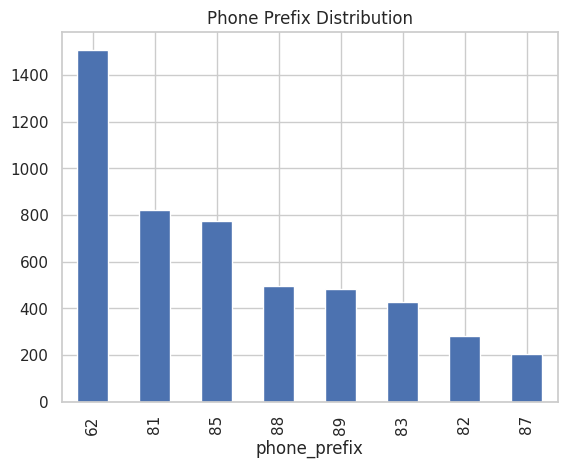

In [16]:
gt["phone_str"] = gt["phone"].astype(str)

# Indonesian numbers often start with 62 or 08
gt["phone_prefix"] = gt["phone_str"].str[:2]

plt.figure()
gt["phone_prefix"].value_counts().head(10).plot(kind="bar")
plt.title("Phone Prefix Distribution")
plt.show()

Address Length & Noise

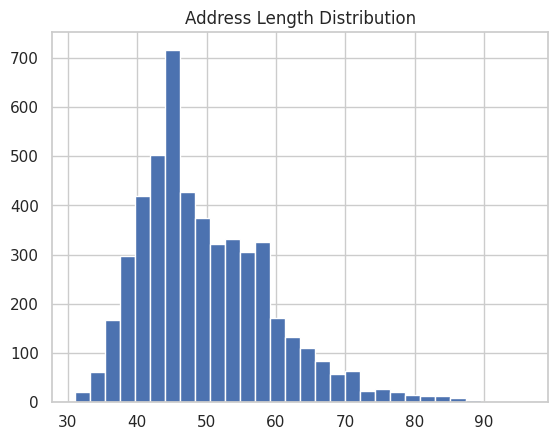

In [17]:
gt["address_len"] = gt["address"].astype(str).apply(len)

plt.figure()
gt["address_len"].hist(bins=30)
plt.title("Address Length Distribution")
plt.show()

In [19]:
# Detect truncation / ellipsis
gt["address_truncated"] = gt["address"].str.contains(r"\.\.\.")
print("Truncated address ratio:", gt["address_truncated"].mean())

Truncated address ratio: 0.0


Name Complexity

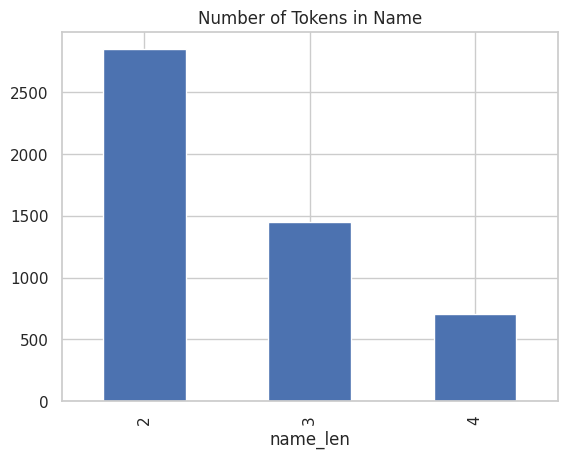

In [21]:
gt["name_len"] = gt["name"].apply(lambda x: len(str(x).split()))

plt.figure()
gt["name_len"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Tokens in Name")
plt.show()

In [23]:
# Detect titles (Dr., S.Psi, M.Pd, etc.)
gt["has_title"] = gt["name"].str.contains(r"\b(S\.|M\.|Dr|Ir)\b", regex=True)
print("Names with titles ratio:", gt["has_title"].mean())

Names with titles ratio: 0.3088


/tmp/ipykernel_1687/501775530.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gt["has_title"] = gt["name"].str.contains(r"\b(S\.|M\.|Dr|Ir)\b", regex=True)


Correlation (Numeric Fields)

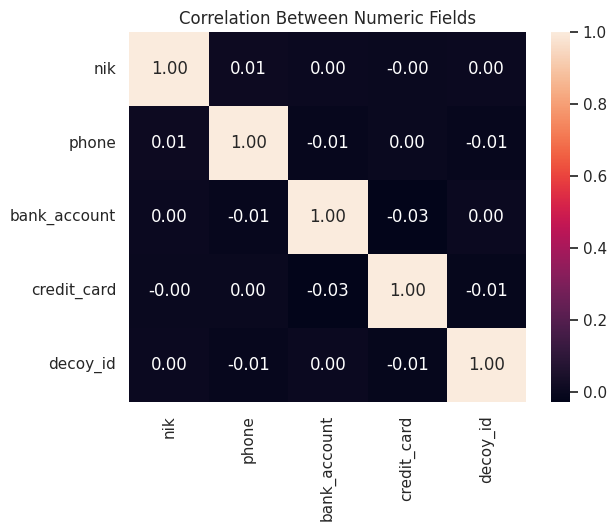

In [25]:
numeric_cols = ["nik", "phone", "bank_account", "credit_card", "decoy_id"]

corr = gt[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Between Numeric Fields")
plt.show()

Decoy vs Real Field Similarity Check

In [28]:
gt["decoy_len"] = gt["decoy_id"].astype(str).apply(len)
gt["nik_len"] = gt["nik"].astype(str).apply(len)

similar_length_ratio = (gt["decoy_len"] == gt["nik_len"]).mean()
print("Decoy matches NIK length ratio:", similar_length_ratio)

Decoy matches NIK length ratio: 1.0
